In [45]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import os
# os.chdir('D:/thesis_code/keypoint_matcher')
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import math


# torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# CSV Maker

In [47]:
# threshold = 26
# patch_size = 32

# threshold = 56
# patch_size = 64

threshold = 10
patch_size = 16

=> Error statistics:
{'count_above_threshold_target_error': 23017,
 'count_above_threshold_x': 12658,
 'count_above_threshold_y': 14866,
 'max_reference_error': 336.12,
 'max_target_error': 514.73,
 'mean_reference_error': 20.04,
 'mean_target_error': 2.76,
 'median_reference_error': 14.52,
 'median_target_error': 1.1,
 'min_reference_error': 0.0,
 'min_target_error': 0.0,
 'std_dev_reference_error': 19.46,
 'std_dev_target_error': 8.27}
=> Estimate Accuracy percentages:
Accuracy within 90 pixels: 99.81%
Accuracy within 60 pixels: 99.51%
Accuracy within 30 pixels: 98.52%
Accuracy within 25 pixels: 98.15%
Accuracy within 5 pixels: 92.15%
Accuracy within 2 pixels: 76.22%
Accuracy within 1.5 pixels: 65.27%
Accuracy within 1.25 pixels: 56.41%
Accuracy within 1 pixels: 45.09%
=> Number of high-error rows per dataset:
dataset
MGO02_hand_puncher            4448
MGO03_hand_shooter_easy       3636
MGO04_hand_shooter_hard       3477
MOO02_hand_puncher_2          2617
MOO04_hand_shooter_hard     

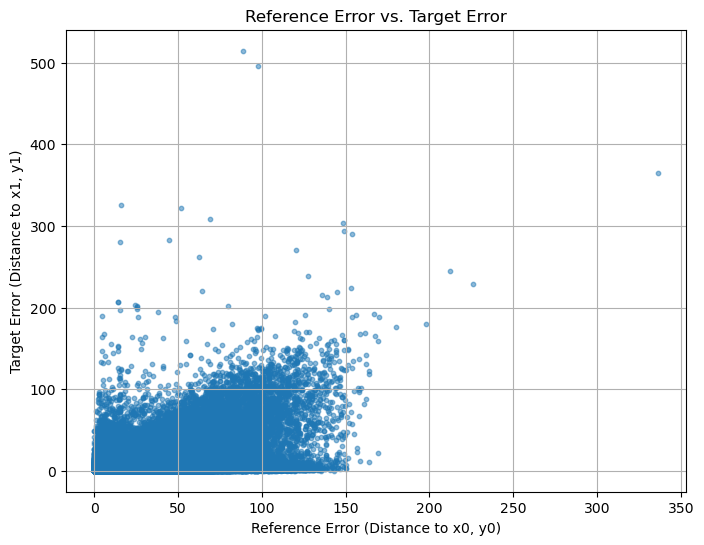

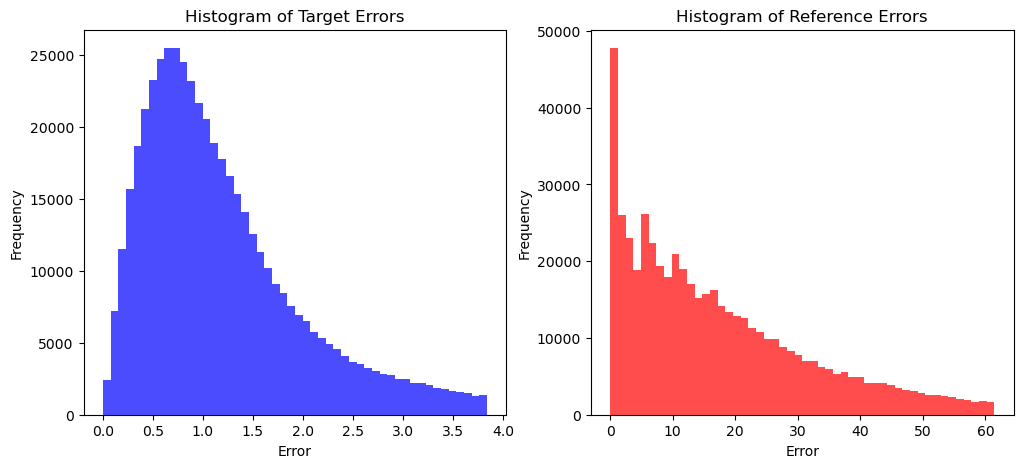

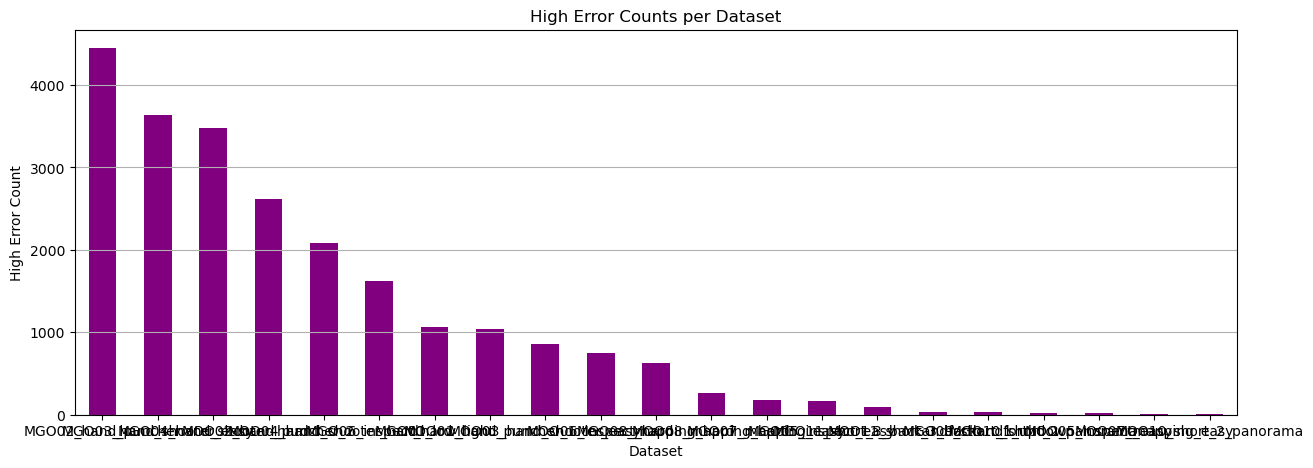

Done!


In [48]:
from prep_1_distance_to_target import main

main(threshold)

In [49]:
from prep_2_create_splits import main

main(threshold, patch_size)

len(training_df)=544033
len(clean_df)=494613
len(centered_df)=494613
Valid rows: 309323
Invalid rows: 309323
=> Dataset Stats:
Train dataset size: 618646 (61.53%)
Validation dataset size: 215430 (21.43%)
Test dataset size: 171294 (17.04%)
Total cleaned dataset size: 1005370 (100%)
Done!


In [50]:
import pandas as pd

csv_path = "/home/stud/ath/ath_ws/datasets/match_april/56/train.csv"
df = pd.read_csv(csv_path)

# df[df["valid"] == False].head()

df.head()

,dataset,cam,kpid,pair_name,x0,y0,x1,y1,x_guess,y_guess,certainty,valid
0,MOO01_hand_puncher_1,0,6.0,7465126824890_7465160114090,128.002899,76.029915,128.460968,76.379158,128.009567,76.006332,0.956268,True
1,MOO01_hand_puncher_1,0,16.0,7465126824890_7465160114090,233.753555,44.724400,233.604706,44.791782,233.759933,44.698345,0.217508,True
2,MOO01_hand_puncher_1,0,44.0,7465126824890_7465160114090,476.477448,43.833572,476.315216,43.603176,476.489258,43.797989,0.917963,True
3,MOO01_hand_puncher_1,0,52.0,7465126824890_7465160114090,557.045044,220.707291,557.698975,220.737442,557.065430,220.675842,0.755588,True
4,MOO01_hand_puncher_1,0,22.0,7465160114090_7465193409290,225.831238,320.724182,225.273132,320.661255,225.831604,320.697357,0.976537,True


In [51]:
nan_exists = df.isnull().values.any() 
nan_exists

False

In [52]:
conf_threhold = 0.25
df[df['certainty'] > conf_threhold].shape, df[df['certainty'] <= conf_threhold].shape

((97670, 12), (148106, 12))